In [3]:
import scipy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# Make dataframe of calibration data

calib_data_no_ambe = {
        'isotope': ['Cs', 'Co', 'Na1', 'Na2', 'Eu1', 'Eu2'],
        'Ee': [0.4758, 1.1157, 0.3755, 1.0670, 0.9033, 1.1937],
    'A': [686.381, 1580.3, 515.64, 1548.8, 1285.5, 1688.6]
}

calib_data_with_ambe = {
    'isotope': ['Cs', 'Co', 'Na1', 'Na2', 'Eu1', 'Eu2', 'AmBe'],
    'Ee': [0.4758, 1.1157, 0.3755, 1.0670, 0.9033, 1.1937, 4.1984],
    'A': [686.381, 1580.3, 515.64, 1548.8, 1285.5, 1688.6, 2900.0]
}

calib_df = pd.DataFrame(calib_data_with_ambe)
calib_df

,isotope,Ee,A
0,Cs,0.4758,686.381
1,Co,1.1157,1580.300
2,Na1,0.3755,515.640
3,Na2,1.0670,1548.800
4,Eu1,0.9033,1285.500
5,Eu2,1.1937,1688.600
6,AmBe,4.1984,2900.000


In [5]:
x = calib_df['Ee']
y = calib_df['A']

In [6]:
# Polynomial curve fit

p = np.polyfit(x, y, deg=3)
print(p)

[ -33.85264325  -73.44743869 1612.7643009   -71.19188733]


Text(0.5, 1.0, 'Polyfit version')

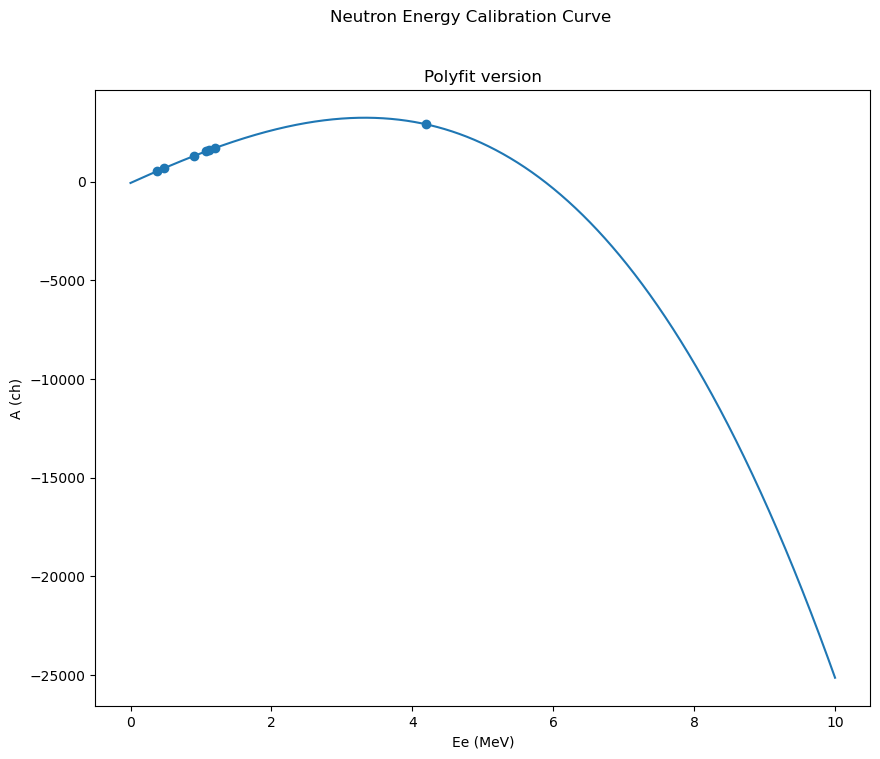

In [7]:
# Polyfit plot
plot_x = np.linspace(0, 10, 10000)
poly_y = np.poly1d(p)
plot_y = poly_y(plot_x)

fig, ax = plt.subplots(figsize=(10,8))
ax.scatter(x, y)
ax.plot(plot_x, plot_y)
# ax.set_xlim(0,2)
# ax.set_ylim(0,2000)
ax.set_xlabel('Ee (MeV)')
ax.set_ylabel('A (ch)')
fig.suptitle('Neutron Energy Calibration Curve')
ax.set_title('Polyfit version')

In [8]:
# Log curve fitting

def calib_curve_fn(ee: float, a: float, b: float, c: float) -> float:
    return a*np.log(b*ee+1) + c*ee

popt, pcov = scipy.optimize.curve_fit(
    calib_curve_fn, x, y, 
#     p0=[2900.0, 2.1, 0.0], 
    bounds=(
        [0.0, -10.0, -10.0],
        [6000.0, 100.0, 1000.0]
    ),
    maxfev=25600)
print(popt)
print(np.sqrt(np.diag(pcov)))

[1470.73982273    1.60244639  -10.        ]
[2045.1731275     2.50062249  529.61437907]


Text(0.5, 1.0, 'Log Curve version')

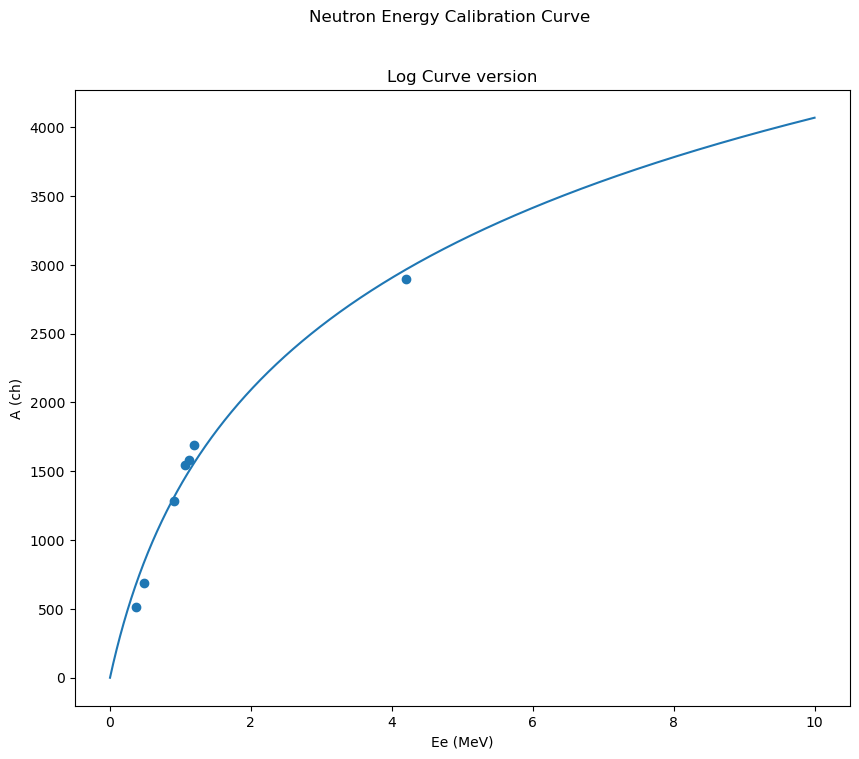

In [9]:
a, b, c = popt
plot_x = np.linspace(0, 10, 10000)
plot_y = calib_curve_fn(plot_x, a, b, c)

fig, ax = plt.subplots(figsize=(10,8))
ax.scatter(x, y)
ax.plot(plot_x, plot_y)
# ax.set_xlim(0,2)
# ax.set_ylim(0,2000)
ax.set_xlabel('Ee (MeV)')
ax.set_ylabel('A (ch)')
fig.suptitle('Neutron Energy Calibration Curve')
ax.set_title('Log Curve version')

Text(0.5, 1.0, 'Log Curve version')

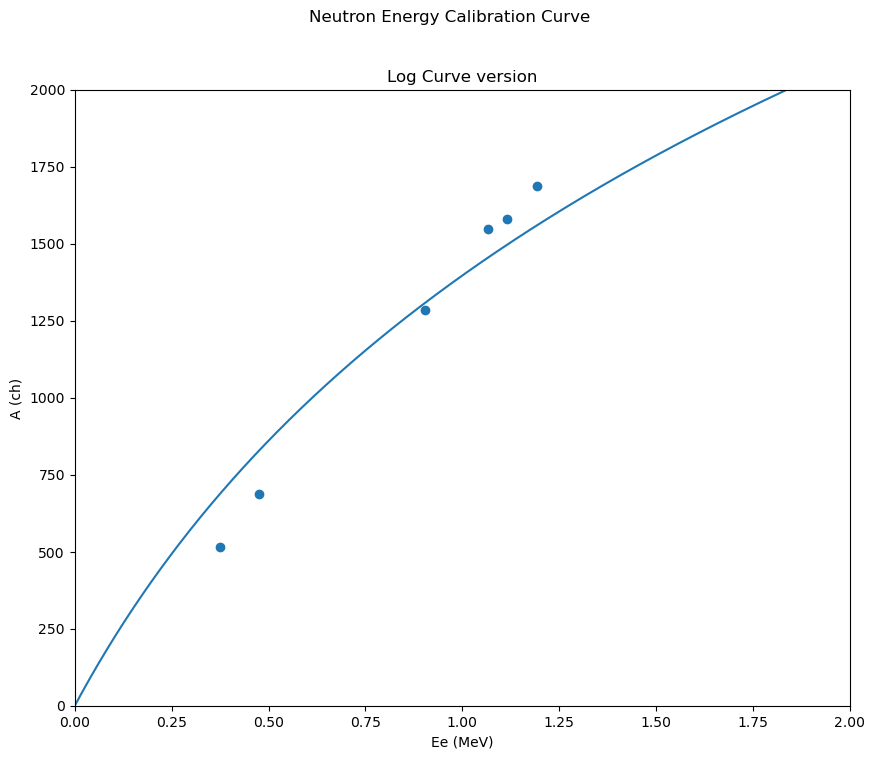

In [11]:
a, b, c = popt
plot_x = np.linspace(0, 10, 10000)
plot_y = calib_curve_fn(plot_x, a, b, c)

fig, ax = plt.subplots(figsize=(10,8))
ax.scatter(x, y)
ax.plot(plot_x, plot_y)
ax.set_xlim(0,2)
ax.set_ylim(0,2000)
ax.set_xlabel('Ee (MeV)')
ax.set_ylabel('A (ch)')
fig.suptitle('Neutron Energy Calibration Curve')
ax.set_title('Log Curve version')